Train: 2015-01-02 to 2024-12-31 (2608 rows)
Test:  2025-01-01 to 2026-06-29 (389 rows)


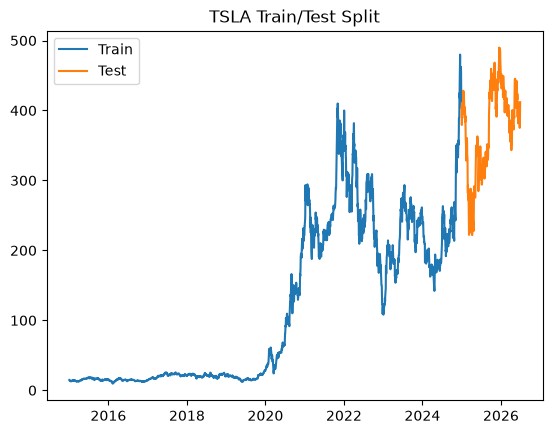

In [3]:
import sys
sys.path.append("..")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("../data/processed/cleaned_combined.csv", index_col=0, parse_dates=True)
tsla = df[df["Ticker"] == "TSLA"][["Close"]].copy()

train = tsla[tsla.index < "2025-01-01"]
test = tsla[tsla.index >= "2025-01-01"]

print(f"Train: {train.index.min().date()} to {train.index.max().date()} ({len(train)} rows)")
print(f"Test:  {test.index.min().date()} to {test.index.max().date()} ({len(test)} rows)")

fig, ax = plt.subplots()
ax.plot(train.index, train["Close"], label="Train")
ax.plot(test.index, test["Close"], label="Test")
ax.set_title("TSLA Train/Test Split")
ax.legend()
plt.show()

In [4]:
import pmdarima as pm

auto_model = pm.auto_arima(
    train["Close"],
    start_p=0, start_q=0,
    max_p=5, max_q=5,
    d=None,               # let auto_arima determine differencing via ADF-style tests
    seasonal=False,       # stock prices don't have strong fixed seasonality; SARIMA tested separately below
    trace=True,           # prints each combination tried
    error_action="ignore",
    suppress_warnings=True,
    stepwise=True,        # smart search instead of brute-force grid (much faster)
)

print(auto_model.summary())

Performing stepwise search to minimize aic
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=16873.591, Time=0.29 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=16875.541, Time=0.27 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=16875.541, Time=0.28 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=16873.127, Time=0.17 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=16877.541, Time=0.37 sec

Best model:  ARIMA(0,1,0)(0,0,0)[0]          
Total fit time: 1.443 seconds
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                 2608
Model:               SARIMAX(0, 1, 0)   Log Likelihood               -8435.563
Date:                Mon, 06 Jul 2026   AIC                          16873.127
Time:                        20:19:18   BIC                          16878.993
Sample:                    01-02-2015   HQIC                         16875.252
                         - 12-31-2024                                  

In [5]:
from statsmodels.tsa.arima.model import ARIMA

order = auto_model.order  # (p, d, q) chosen by auto_arima
print(f"Selected order: {order}")

arima_model = ARIMA(train["Close"], order=order)
arima_fit = arima_model.fit()
print(arima_fit.summary())

n_periods = len(test)
forecast_result = arima_fit.get_forecast(steps=n_periods)
arima_forecast = forecast_result.predicted_mean
arima_conf_int = forecast_result.conf_int(alpha=0.05)

arima_forecast.index = test.index
arima_conf_int.index = test.index

Selected order: (0, 1, 0)


c:\Users\pc\portfolio-optimization\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency B will be used.
  self._init_dates(dates, freq)
c:\Users\pc\portfolio-optimization\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency B will be used.
  self._init_dates(dates, freq)
c:\Users\pc\portfolio-optimization\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency B will be used.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:                  Close   No. Observations:                 2608
Model:                 ARIMA(0, 1, 0)   Log Likelihood               -8435.563
Date:                Mon, 06 Jul 2026   AIC                          16873.127
Time:                        20:19:18   BIC                          16878.993
Sample:                    01-02-2015   HQIC                         16875.252
                         - 12-31-2024                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
sigma2        37.8492      0.410     92.238      0.000      37.045      38.653
Ljung-Box (L1) (Q):                   0.05   Jarque-Bera (JB):             13283.42
Prob(Q):                              0.82   Pr

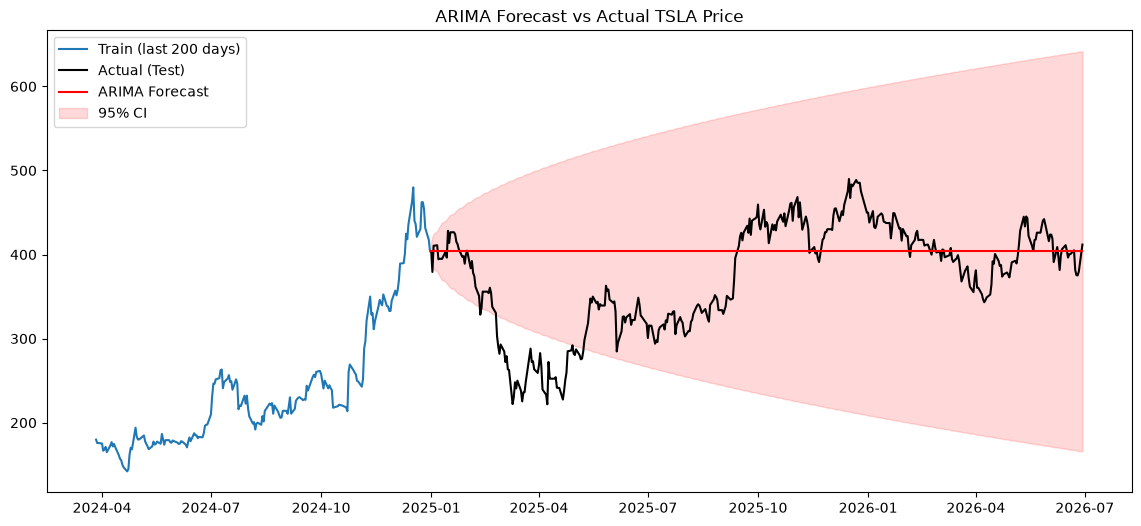

In [6]:
fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(train.index[-200:], train["Close"].iloc[-200:], label="Train (last 200 days)")
ax.plot(test.index, test["Close"], label="Actual (Test)", color="black")
ax.plot(arima_forecast.index, arima_forecast, label="ARIMA Forecast", color="red")
ax.fill_between(
    arima_conf_int.index,
    arima_conf_int.iloc[:, 0],
    arima_conf_int.iloc[:, 1],
    color="red", alpha=0.15, label="95% CI"
)
ax.set_title("ARIMA Forecast vs Actual TSLA Price")
ax.legend()
plt.show()

In [7]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

def evaluate(actual, predicted, label):
    mae = mean_absolute_error(actual, predicted)
    rmse = np.sqrt(mean_squared_error(actual, predicted))
    mape = np.mean(np.abs((actual - predicted) / actual)) * 100
    print(f"--- {label} ---")
    print(f"MAE:  {mae:.2f}")
    print(f"RMSE: {rmse:.2f}")
    print(f"MAPE: {mape:.2f}%\n")
    return {"MAE": mae, "RMSE": rmse, "MAPE": mape}

arima_scores = evaluate(test["Close"], arima_forecast, "ARIMA")

--- ARIMA ---
MAE:  54.15
RMSE: 70.20
MAPE: 17.11%



In [8]:
from sklearn.preprocessing import MinMaxScaler

WINDOW = 60  # use last 60 days to predict next day

# Scale using ONLY training data statistics to avoid leaking test info
scaler = MinMaxScaler(feature_range=(0, 1))
train_scaled = scaler.fit_transform(train[["Close"]])

# For the test period, we need the WINDOW days immediately preceding it too
full_series = pd.concat([train["Close"], test["Close"]])
full_scaled = scaler.transform(full_series.values.reshape(-1, 1))

def create_sequences(data, window):
    X, y = [], []
    for i in range(window, len(data)):
        X.append(data[i - window:i, 0])
        y.append(data[i, 0])
    return np.array(X), np.array(y)

X_train, y_train = create_sequences(train_scaled, WINDOW)

# Test sequences: start WINDOW days before test begins, so first prediction
# corresponds to the first test-set day
test_start_idx = len(train_scaled) - WINDOW
test_scaled_with_lookback = full_scaled[test_start_idx:]
X_test, y_test = create_sequences(test_scaled_with_lookback, WINDOW)

# LSTM expects 3D input: (samples, timesteps, features)
X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_test = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")

X_train shape: (2548, 60, 1)
X_test shape: (389, 60, 1)


c:\Users\pc\portfolio-optimization\venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


In [9]:
import torch
import torch.nn as nn

device = torch.device("cpu")  # low-RAM machine, CPU is fine for this dataset size

# Convert numpy arrays to PyTorch tensors
X_train_t = torch.tensor(X_train, dtype=torch.float32).to(device)
y_train_t = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1).to(device)
X_test_t = torch.tensor(X_test, dtype=torch.float32).to(device)

class LSTMModel(nn.Module):
    def __init__(self, input_size=1, hidden_size=50, num_layers=2, dropout=0.2):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout
        )
        self.fc1 = nn.Linear(hidden_size, 25)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(25, 1)

    def forward(self, x):
        lstm_out, _ = self.lstm(x)
        last_step = lstm_out[:, -1, :]  # take output from the final time step
        x = self.relu(self.fc1(last_step))
        return self.fc2(x)

model = LSTMModel().to(device)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

print(model)

LSTMModel(
  (lstm): LSTM(1, 50, num_layers=2, batch_first=True, dropout=0.2)
  (fc1): Linear(in_features=50, out_features=25, bias=True)
  (relu): ReLU()
  (fc2): Linear(in_features=25, out_features=1, bias=True)
)


Epoch 1/20 - loss: 0.035399 - val_loss: 0.020745
Epoch 2/20 - loss: 0.002568 - val_loss: 0.006286
Epoch 3/20 - loss: 0.001431 - val_loss: 0.004348
Epoch 4/20 - loss: 0.001210 - val_loss: 0.003894
Epoch 5/20 - loss: 0.001118 - val_loss: 0.003003
Epoch 6/20 - loss: 0.000861 - val_loss: 0.002641
Epoch 7/20 - loss: 0.000862 - val_loss: 0.002155
Epoch 8/20 - loss: 0.000807 - val_loss: 0.002121
Epoch 9/20 - loss: 0.000834 - val_loss: 0.002315
Epoch 10/20 - loss: 0.000796 - val_loss: 0.001972
Epoch 11/20 - loss: 0.000704 - val_loss: 0.002053
Epoch 12/20 - loss: 0.000729 - val_loss: 0.001580
Epoch 13/20 - loss: 0.000674 - val_loss: 0.002061
Epoch 14/20 - loss: 0.000602 - val_loss: 0.001505
Epoch 15/20 - loss: 0.000579 - val_loss: 0.001879
Epoch 16/20 - loss: 0.000608 - val_loss: 0.001609
Epoch 17/20 - loss: 0.000581 - val_loss: 0.001461
Epoch 18/20 - loss: 0.000559 - val_loss: 0.001580
Epoch 19/20 - loss: 0.000532 - val_loss: 0.001341
Epoch 20/20 - loss: 0.000512 - val_loss: 0.001232


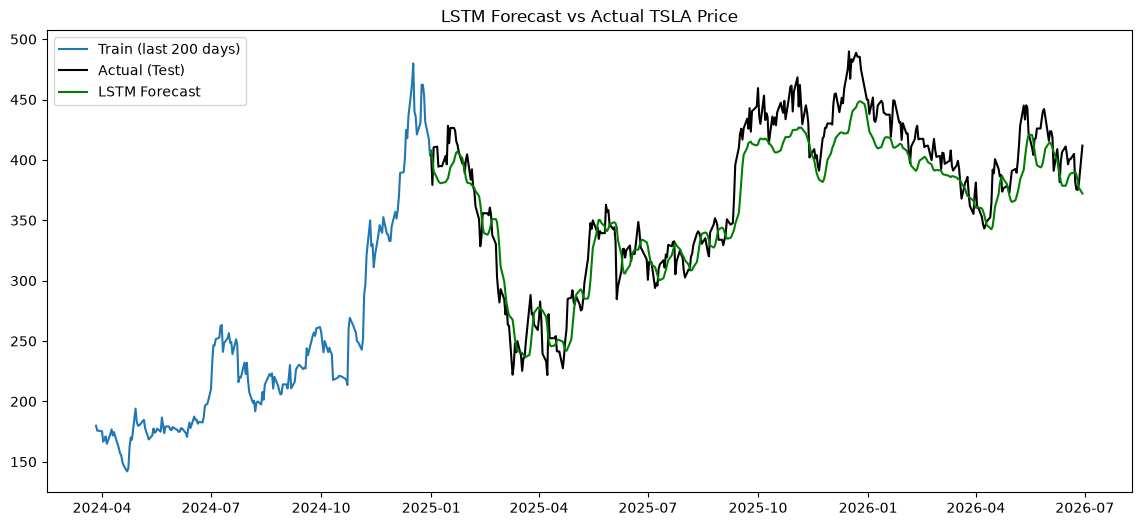

In [10]:
from torch.utils.data import TensorDataset, DataLoader

# Split off 10% for validation, same as Keras validation_split=0.1
val_size = int(0.1 * len(X_train_t))
train_ds = TensorDataset(X_train_t[:-val_size], y_train_t[:-val_size])
val_ds = TensorDataset(X_train_t[-val_size:], y_train_t[-val_size:])

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=32, shuffle=False)

EPOCHS = 20
for epoch in range(EPOCHS):
    model.train()
    train_loss = 0
    for xb, yb in train_loader:
        optimizer.zero_grad()
        pred = model(xb)
        loss = criterion(pred, yb)
        loss.backward()
        optimizer.step()
        train_loss += loss.item() * xb.size(0)
    train_loss /= len(train_ds)

    model.eval()
    val_loss = 0
    with torch.no_grad():
        for xb, yb in val_loader:
            pred = model(xb)
            val_loss += criterion(pred, yb).item() * xb.size(0)
    val_loss /= len(val_ds)

    print(f"Epoch {epoch+1}/{EPOCHS} - loss: {train_loss:.6f} - val_loss: {val_loss:.6f}")

# Generate predictions on test set
model.eval()
with torch.no_grad():
    lstm_pred_scaled = model(X_test_t).numpy()

lstm_forecast = scaler.inverse_transform(lstm_pred_scaled).flatten()
lstm_forecast = pd.Series(lstm_forecast, index=test.index)

fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(train.index[-200:], train["Close"].iloc[-200:], label="Train (last 200 days)")
ax.plot(test.index, test["Close"], label="Actual (Test)", color="black")
ax.plot(lstm_forecast.index, lstm_forecast, label="LSTM Forecast", color="green")
ax.set_title("LSTM Forecast vs Actual TSLA Price")
ax.legend()
plt.show()

In [11]:
lstm_scores = evaluate(test["Close"].values, lstm_forecast.values, "LSTM")

comparison = pd.DataFrame({
    "ARIMA": arima_scores,
    "LSTM": lstm_scores
}).T
comparison

--- LSTM ---
MAE:  18.09
RMSE: 22.31
MAPE: 4.82%



,MAE,RMSE,MAPE
ARIMA,54.151953,70.196786,17.112171
LSTM,18.088096,22.309691,4.820128


In [12]:
FORECAST_DAYS = 252  # ~12 months of trading days

def mc_dropout_forecast(model, last_window_scaled, n_days, n_simulations=100):
    """
    Generates n_days of future predictions, n_simulations times, with dropout
    left ACTIVE at inference time (model.train() instead of model.eval()).
    Each simulation produces a slightly different path because dropout randomly
    drops connections — the spread across simulations approximates the model's
    uncertainty about the future.
    """
    model.train()  # keep dropout active on purpose
    all_paths = []

    for sim in range(n_simulations):
        window = last_window_scaled.copy()
        path = []
        with torch.no_grad():
            for _ in range(n_days):
                x = torch.tensor(window.reshape(1, -1, 1), dtype=torch.float32)
                pred = model(x).item()
                path.append(pred)
                window = np.append(window[1:], pred)  # slide window forward
        all_paths.append(path)

    return np.array(all_paths)  # shape: (n_simulations, n_days)

# Start from the last WINDOW days of the full known series (scaled)
last_window = full_scaled[-WINDOW:].flatten()

paths_scaled = mc_dropout_forecast(model, last_window, FORECAST_DAYS, n_simulations=100)

# Inverse-transform every simulated path back to dollar terms
paths_dollars = np.array([
    scaler.inverse_transform(p.reshape(-1, 1)).flatten() for p in paths_scaled
])

# Summarize across simulations: median forecast + 95% interval
forecast_median = np.median(paths_dollars, axis=0)
forecast_lower = np.percentile(paths_dollars, 2.5, axis=0)
forecast_upper = np.percentile(paths_dollars, 97.5, axis=0)

future_dates = pd.bdate_range(start=tsla.index[-1] + pd.Timedelta(days=1), periods=FORECAST_DAYS)

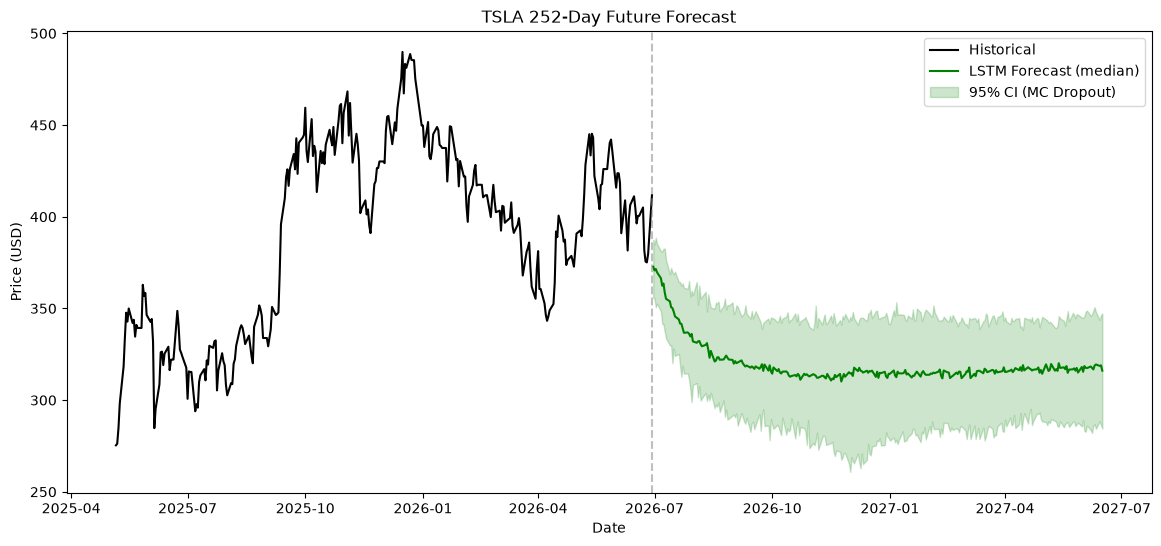

Forecast horizon: 2026-06-30 to 2027-06-16
Starting price: $411.84
Median forecast at horizon end: $316.06
95% CI at horizon end: [$284.49, $347.25]
CI width at day 1: $31.54
CI width at day 252: $62.76


In [13]:
fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(tsla.index[-300:], tsla["Close"].iloc[-300:], label="Historical", color="black")
ax.plot(future_dates, forecast_median, label="LSTM Forecast (median)", color="green")
ax.fill_between(future_dates, forecast_lower, forecast_upper, color="green", alpha=0.2, label="95% CI (MC Dropout)")
ax.axvline(tsla.index[-1], color="gray", linestyle="--", alpha=0.5)
ax.set_title(f"TSLA {FORECAST_DAYS}-Day Future Forecast")
ax.set_xlabel("Date")
ax.set_ylabel("Price (USD)")
ax.legend()
plt.show()

print(f"Forecast horizon: {future_dates[0].date()} to {future_dates[-1].date()}")
print(f"Starting price: ${tsla['Close'].iloc[-1]:.2f}")
print(f"Median forecast at horizon end: ${forecast_median[-1]:.2f}")
print(f"95% CI at horizon end: [${forecast_lower[-1]:.2f}, ${forecast_upper[-1]:.2f}]")
print(f"CI width at day 1: ${(forecast_upper[0] - forecast_lower[0]):.2f}")
print(f"CI width at day {FORECAST_DAYS}: ${(forecast_upper[-1] - forecast_lower[-1]):.2f}")

## Task 3: Trend Analysis and Business Insights

**Trend direction:** The LSTM forecasts a moderate decline in TSLA price over the 
12-month horizon (June 2026 – June 2027), from $411.84 to a median of $316.06 
(-23.3%), with most of the decline occurring in the first 2-3 months before the 
forecast plateaus and stabilizes around $310-320.

**Confidence interval widening:** The 95% CI widens from $31.54 at day 1 to $62.76 
at day 252 — roughly double, but far more contained than ARIMA's confidence 
interval, which fanned out to several hundred dollars over a similar horizon. 
This narrower growth reflects a genuine limitation of the iterative forecasting 
approach: because each day's prediction feeds into the next day's input, the 
model tends to converge toward a stable "attractor" value rather than genuinely 
projecting increasing uncertainty the way a statistical model's confidence 
interval does. In practice, this means the LSTM's apparent precision at long 
horizons should be treated with skepticism — the true uncertainty 12 months out 
is almost certainly larger than this interval suggests.

**Opportunities:** If the forecast direction proves accurate, this presents a 
potential **entry point after the anticipated decline** — the plateau near 
$310-320 could represent a more attractive valuation for a long-term position, 
assuming GMF's broader investment thesis on Tesla's fundamentals remains intact.

**Risks:** 
- A projected 23% decline is a substantial downside risk for any near-term 
  long position in TSLA specifically.
- The forecast's flattening behavior is a known artifact of iterative multi-step 
  LSTM forecasting (error accumulation compounds this into a "mean-reverting" 
  pattern), not necessarily a genuine market signal — this should temper how 
  much weight is placed on the point forecast itself.
- TSLA's historical volatility (56% annualized, per Task 1) means actual 
  outcomes could diverge sharply from either the median forecast or the stated 
  CI in either direction.

**Reliability assessment across horizons:** Near-term (1-3 month) forecasts 
should be treated with more confidence than the 9-12 month plateau region, 
since the model has less basis for projecting that far and the CI, while 
technically present, likely understates true long-horizon uncertainty. This 
forecast is best used as one input among several (per GMF's advisory approach) 
rather than a standalone prediction to act on directly.